<a href="https://colab.research.google.com/github/jbkim900/Big-data-Analysis-Class_2026.03.12/blob/main/8%EC%9E%A5_English_Word_Analysis_2026_03_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 8장. 텍스트 빈도 분석 (1)영어단어분석

In [ ]:
!pip install matplotlib

In [1]:
!pip install wordcloud

### - 자연어처리패키지 nltk download

In [2]:
import nltk

In [ ]:
# nltk.download()

#### -----------------------------------------------------------------

# 4. 데이터 준비

In [4]:
import pandas as pd
import glob
import re
from functools import reduce

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import STOPWORDS, WordCloud

## 데이터 조합 – 파일 병합하기

In [8]:
all_files = glob.glob('/content/myCabinetExcelData*.xlsx')
all_files #출력하여 내용 확인

['/content/myCabinetExcelData (5).xlsx',
 '/content/myCabinetExcelData (1).xlsx',
 '/content/myCabinetExcelData (3).xlsx',
 '/content/myCabinetExcelData.xlsx',
 '/content/myCabinetExcelData (2).xlsx',
 '/content/myCabinetExcelData (4).xlsx',
 '/content/myCabinetExcelData (9).xlsx',
 '/content/myCabinetExcelData (6).xlsx',
 '/content/myCabinetExcelData (8).xlsx',
 '/content/myCabinetExcelData (7).xlsx']

In [9]:
#"ImportError: Missing optional dependency 'xlrd'." 에러 발생 시, xlrd 패키지 설치하기
!pip install xlrd

In [10]:
all_files_data = [] #저장할 리스트
for file in all_files:
    data_frame = pd.read_excel(file)
    all_files_data.append(data_frame)

all_files_data[0] #작업 내용 확인

,Unnamed: 0,번호,제목,저자,출판사,출판일
0,NaN,1,Performance Meta-analysis for Big-Data Univari...,"Stefanopoulou, Aliki",Springer,2022
1,NaN,2,Semantic interoperability for big-data in hete...,"Ullah, Farhan; Habib, Muhammad Asif; Farhan, M...",Elsevier Science,2017
2,NaN,3,A Middleware for Managing Big-Data Flows,"Gupta, R.; Gupta, H.; Gupta, S.; Padmanabhan, S.",SPRINGER-VERLAG,2013
3,NaN,4,Ari Caroline: This big-data guru mines analyti...,"Nordrum, A.",IEEE INSTITUTE OF ELECTRICAL AND ELECTRONICS,2016
4,NaN,5,Smallholders need access to big-data agronomy too,"Mehrabi, Z.; Jimenez, D.; Jarvis, A.",Nature Publishing Group,2018
...,...,...,...,...,...,...
95,NaN,96,Risk Assessment of Secondary Primary Malignanc...,"Zhang, Lu-Lu; Li, Guo-Hong; Li, Yi-Yang; Qi, Z...",Korean Cancer Association,2019
96,NaN,97,Optimization assisted bidirectional gated recu...,"Shukla, Prashant Kumar;Stalin, Shalini;Joshi, ...",Elsevier,2023
97,NaN,98,Special issue on trends in high‐performance in...,"Escudero‐Sahuquillo, Jesús; Garcia, Pedro Javier","John Wiley & Sons, Ltd",2017
98,NaN,99,Stochastic Decision Making for Adaptive Crowds...,"Kim, J.; Lee, W.",IEEE,2015


In [11]:
all_files_data_concat = pd.concat( all_files_data, axis = 0, ignore_index = True)
all_files_data_concat #출력하여 내용 확인

,Unnamed: 0,번호,제목,저자,출판사,출판일
0,NaN,1,Performance Meta-analysis for Big-Data Univari...,"Stefanopoulou, Aliki",Springer,2022
1,NaN,2,Semantic interoperability for big-data in hete...,"Ullah, Farhan; Habib, Muhammad Asif; Farhan, M...",Elsevier Science,2017
2,NaN,3,A Middleware for Managing Big-Data Flows,"Gupta, R.; Gupta, H.; Gupta, S.; Padmanabhan, S.",SPRINGER-VERLAG,2013
3,NaN,4,Ari Caroline: This big-data guru mines analyti...,"Nordrum, A.",IEEE INSTITUTE OF ELECTRICAL AND ELECTRONICS,2016
4,NaN,5,Smallholders need access to big-data agronomy too,"Mehrabi, Z.; Jimenez, D.; Jarvis, A.",Nature Publishing Group,2018
...,...,...,...,...,...,...
995,NaN,96,Big Data: A Framework for Research,"Nagle, T.; Sammon, D.",IOS Press,2014
996,NaN,97,"""Big Data"" Meets ""Smart Beta""",RICHARD C. DAVIS,Institutional Investor,2015
997,NaN,98,``Big Data'' Has Not Come to Pediatric Anesthesia,"Fisher, D.M.",Lippincott Williams & Wilkins,2014
998,NaN,99,Big Data—Go `Granular' to Boost Sales We look ...,unknown,TRSA,2019


In [12]:
all_files_data_concat.to_csv( 'riss_bigdata.csv', encoding = 'utf-8', index = False)

## 데이터 전처리

In [13]:
all_title = all_files_data_concat['제목']
all_title #출력하여 내용 확인

,제목
0,Performance Meta-analysis for Big-Data Univari...
1,Semantic interoperability for big-data in hete...
2,A Middleware for Managing Big-Data Flows
3,Ari Caroline: This big-data guru mines analyti...
4,Smallholders need access to big-data agronomy too
...,...
995,Big Data: A Framework for Research
996,"""Big Data"" Meets ""Smart Beta"""
997,``Big Data'' Has Not Come to Pediatric Anesthesia
998,Big Data—Go `Granular' to Boost Sales We look ...


In [14]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
stopWords = set(stopwords.words("english"))
lemma = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [15]:
words = []
for title in all_title:
    EnWords = re.sub(r"[^a-zA-Z]+", " ", str(title))
    EnWordsToken = word_tokenize(EnWords.lower())
    EnWordsTokenStop = [ w for w in EnWordsToken if w not in stopWords]
    EnWordsTokenStopLemma = [ lemma.lemmatize(w) for w in EnWordsTokenStop]
    words.append(EnWordsTokenStopLemma)

In [16]:
print(words) #출력하여 내용 확인

[['performance', 'meta', 'analysis', 'big', 'data', 'univariate', 'auto', 'imputation', 'building', 'sector'], ['semantic', 'interoperability', 'big', 'data', 'heterogeneous', 'iot', 'infrastructure', 'healthcare'], ['middleware', 'managing', 'big', 'data', 'flow'], ['ari', 'caroline', 'big', 'data', 'guru', 'mine', 'analytics', 'help', 'cancer', 'patient', 'resource', 'career'], ['smallholder', 'need', 'access', 'big', 'data', 'agronomy'], ['design', 'implementation', 'big', 'data', 'analysis', 'application', 'spark', 'distribution', 'network', 'based', 'data', 'interception'], ['methodology', 'real', 'time', 'data', 'sustainability', 'smart', 'city', 'towards', 'inferencing', 'analytics', 'big', 'data'], ['code', 'offloading', 'scheme', 'big', 'data', 'processing', 'android', 'application'], ['vergleich', 'von', 'kompetenzanforderungen', 'business', 'intelligence', 'und', 'big', 'data', 'spezialisten'], ['jbhi', 'special', 'issue', 'x', 'c', 'big', 'data', 'health', 'x'], ['rw', 'app

In [17]:
words2 = list(reduce(lambda x, y: x+y, words))
print(words2) #출력하여 내용 확인

['performance', 'meta', 'analysis', 'big', 'data', 'univariate', 'auto', 'imputation', 'building', 'sector', 'semantic', 'interoperability', 'big', 'data', 'heterogeneous', 'iot', 'infrastructure', 'healthcare', 'middleware', 'managing', 'big', 'data', 'flow', 'ari', 'caroline', 'big', 'data', 'guru', 'mine', 'analytics', 'help', 'cancer', 'patient', 'resource', 'career', 'smallholder', 'need', 'access', 'big', 'data', 'agronomy', 'design', 'implementation', 'big', 'data', 'analysis', 'application', 'spark', 'distribution', 'network', 'based', 'data', 'interception', 'methodology', 'real', 'time', 'data', 'sustainability', 'smart', 'city', 'towards', 'inferencing', 'analytics', 'big', 'data', 'code', 'offloading', 'scheme', 'big', 'data', 'processing', 'android', 'application', 'vergleich', 'von', 'kompetenzanforderungen', 'business', 'intelligence', 'und', 'big', 'data', 'spezialisten', 'jbhi', 'special', 'issue', 'x', 'c', 'big', 'data', 'health', 'x', 'rw', 'application', 'artificia

# 5. 데이터 탐색 및 분석 모델 구축

## 1. 데이터 탐색 - 단어 빈도 구하기

In [18]:
count = Counter(words2)
count #출력하여 내용 확인

Counter({'performance': 25,
         'meta': 1,
         'analysis': 97,
         'big': 1112,
         'data': 1239,
         'univariate': 1,
         'auto': 1,
         'imputation': 2,
         'building': 8,
         'sector': 7,
         'semantic': 6,
         'interoperability': 2,
         'heterogeneous': 5,
         'iot': 9,
         'infrastructure': 12,
         'healthcare': 16,
         'middleware': 1,
         'managing': 5,
         'flow': 5,
         'ari': 1,
         'caroline': 1,
         'guru': 1,
         'mine': 3,
         'analytics': 113,
         'help': 7,
         'cancer': 5,
         'patient': 13,
         'resource': 6,
         'career': 2,
         'smallholder': 2,
         'need': 4,
         'access': 6,
         'agronomy': 1,
         'design': 11,
         'implementation': 4,
         'application': 40,
         'spark': 5,
         'distribution': 10,
         'network': 27,
         'based': 102,
         'interception': 1,
         'm

In [19]:
word_count = dict()

for tag, counts in count.most_common(50):
    if(len(str(tag))>1):
        word_count[tag] = counts
        print("%s : %d" % (tag, counts))

data : 1239
big : 1112
analytics : 113
based : 102
analysis : 97
driven : 71
system : 62
approach : 56
using : 56
issue : 48
learning : 48
model : 46
challenge : 44
application : 40
new : 39
special : 37
algorithm : 36
framework : 36
management : 36
research : 34
platform : 34
call : 34
science : 34
paper : 32
health : 31
era : 30
cloud : 30
opportunity : 28
network : 27
processing : 26
technology : 26
mining : 26
machine : 26
performance : 25
method : 25
computing : 25
earth : 25
smart : 24
business : 24
optimization : 24
perspective : 24
information : 23
distributed : 23
use : 23
world : 22
review : 22
process : 22
intelligence : 21
service : 21
real : 20


## 2. 데이터 탐색 - 히스토그램 그리기

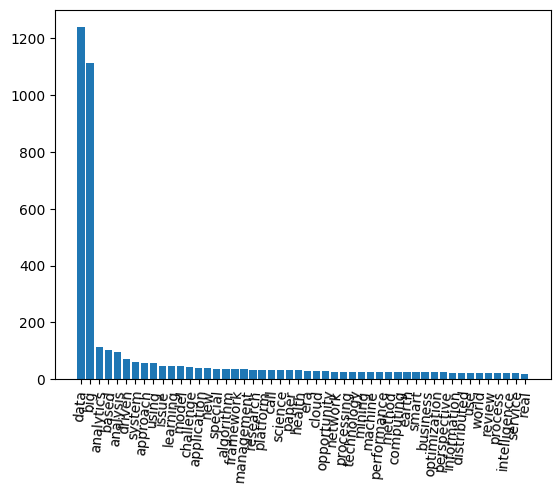

In [20]:
sorted_Keys = sorted(word_count, key = word_count.get, reverse = True)
sorted_Values = sorted(word_count.values(), reverse = True)
plt.bar(range(len(word_count)), sorted_Values, align = 'center')
plt.xticks( range(len(word_count)), list(sorted_Keys), rotation = 85)
plt.show()

###  - 'big', 'data'를 제외하고, 단어빈도 히스토그램 그리기

In [21]:
word_count2 = word_count
del word_count2['big']
del word_count2['data']

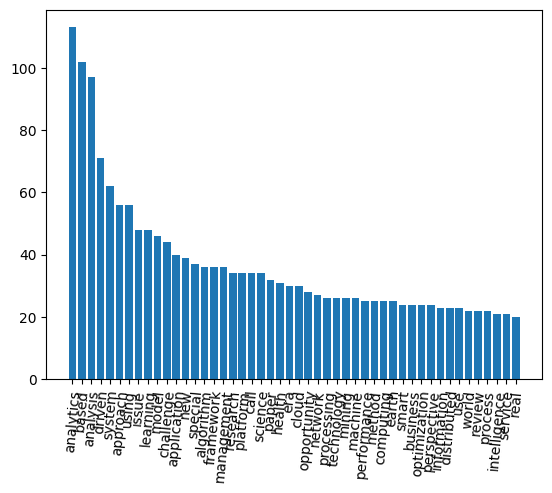

In [22]:
sorted_Keys = sorted(word_count2, key = word_count.get, reverse = True)
sorted_Values = sorted(word_count2.values(), reverse = True)
plt.bar(range(len(word_count2)), sorted_Values, align = 'center')
plt.xticks( range(len(word_count2)), list(sorted_Keys), rotation = 85)
plt.show()

# 6. 결과 시각화

In [23]:
all_files_data_concat['doc_count'] = 0
summary_year = all_files_data_concat.groupby('출판일', as_index = False)['doc_count'].count()
summary_year #출력하여 내용 확인

,출판일,doc_count
0,2003,1
1,2004,1
2,2011,5
3,2012,19
4,2013,50
5,2014,124
6,2015,92
7,2016,112
8,2017,129
9,2018,118


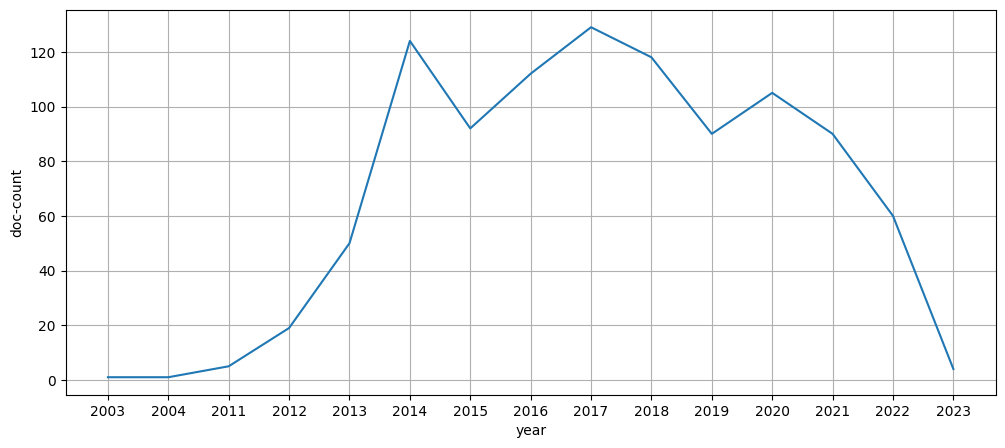

In [24]:
plt.figure(figsize = (12, 5))
plt.xlabel("year")
plt.ylabel("doc-count")
plt.grid(True)
plt.plot(range(len(summary_year)), summary_year['doc_count'])
plt.xticks( range(len(summary_year)), [text for text in summary_year['출판일']])
plt.show()

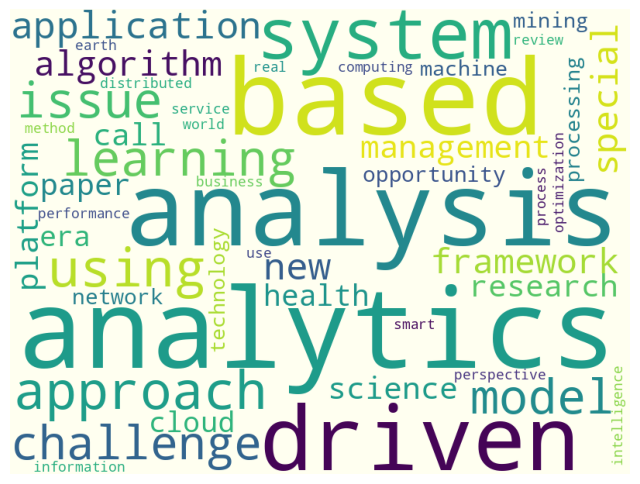

In [25]:
stopwords = set(STOPWORDS)
wc = WordCloud(background_color = 'ivory', stopwords = stopwords,width = 800, height = 600)
cloud = wc.generate_from_frequencies(word_count)
plt.figure(figsize = (8,8))
plt.imshow(cloud)
plt.axis('off')
plt.show()

In [26]:
cloud.to_file("riss_bigdata_wordCloud.jpg")